# Assignment 2 by: Danial Ansari (s4119075) (COSC2670)

In [1]:
# Student: Danial Ansari | Student ID: s4119075 | Course: COSC2670 (PG)
# Tasks completed (PG): 1, 2.1, 2.2B, 2.3, 3.1, 3.2, 3.3B
# Run with Kernel -> Restart & Run All (about 3-4 minutes); A2data.csv must be in the same folder.

## Setup: libraries, constants and plotting style

In [2]:
import os
import time
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, classification_report,
                             silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score)
from sklearn.model_selection import (train_test_split, KFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# ---- Submission constants (file names follow the required CourseCode-StudentNumber pattern) ----
COURSE_CODE = "COSC2670"
STUDENT_ID = "s4119075"
PREFIX = f"{COURSE_CODE}-{STUDENT_ID}"
DATA_FILE = "A2data.csv"
SAMPLE_ONE = f"{PREFIX}-A2SampleOne.csv"      # Task 1 (300 rows)
SAMPLE_TWO = f"{PREFIX}-A2SampleTwo.csv"      # Task 2 (2000 rows)
SAMPLE_THREE = f"{PREFIX}-A2SampleThree.csv"  # Task 3 (2000 rows)

# One fixed seed (the digits of the student number) makes every random step reproducible
RANDOM_STATE = 4119075

# Figures are also written to disk so exactly the same graphs can be used in the report
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ---- Plotting style: colour-blind-checked categorical palette, recessive grid/axes ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK_2, INK_3, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e4e3df"
NOISE_GREY = "#b9b8b3"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 9, "axes.titlesize": 9.5,
    "axes.titleweight": "bold", "axes.labelsize": 9, "axes.edgecolor": INK_3,
    "axes.labelcolor": INK, "axes.titlecolor": INK, "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False,
    "legend.fontsize": 8, "lines.linewidth": 2, "axes.prop_cycle": plt.cycler(color=PALETTE),
})
BLUES = LinearSegmentedColormap.from_list("blues", ["#f4f8fd", "#9ec5f4", "#2a78d6", "#0d366b"])
DIVERGING = LinearSegmentedColormap.from_list("div", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#8f1d1c"])

# Bean classes get a fixed colour AND marker so identity never relies on colour alone
CLASS_ORDER = ["BARBUNYA", "BOMBAY", "CALI", "DERMASON", "HOROZ", "SEKER", "SIRA"]
CLASS_COLOURS = dict(zip(CLASS_ORDER, PALETTE))
CLASS_MARKERS = dict(zip(CLASS_ORDER, ["o", "s", "^", "D", "v", "P", "X"]))


def save_fig(fig, name):
    """Save a figure as PNG into FIG_DIR (used in the report) and show it in the notebook."""
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight", facecolor="white")
    plt.show()


def panel_label(ax, text):
    """Write a small '(a)', '(b)' ... label in the top-left corner of a subplot."""
    ax.text(-0.02, 1.04, text, transform=ax.transAxes, fontsize=9, fontweight="bold",
            color=INK, ha="right", va="bottom")

# Data Sampling

The full dataset is loaded once and checked for missing values, invalid values and exact
duplicate rows. Only complete, unique records are eligible for sampling. Each sample is
drawn **only if its CSV file does not exist yet**; afterwards the saved file is re-used,
so every later analysis in a task works on exactly the same sample (no re-sampling on re-runs).

In [3]:
# Code for creating samples for all tasks
raw = pd.read_csv(DATA_FILE)
print("Shape of the full dataset:", raw.shape)
print("\nData types:\n", raw.dtypes.value_counts().to_string())
print("\nMissing values in the whole dataset:", int(raw.isna().sum().sum()))
print("Exact duplicate rows:", int(raw.duplicated().sum()))

# Sanity check: every morphological measurement must be strictly positive
numeric_cols = raw.columns.drop("Class")
print("Non-positive numeric values:", int((raw[numeric_cols] <= 0).sum().sum()))
print("\nClass distribution (full data):\n", raw["Class"].value_counts().to_string())

Shape of the full dataset: (13611, 17)

Data types:
 float64    14
int64       2
str         1

Missing values in the whole dataset: 0
Exact duplicate rows: 68
Non-positive numeric values: 0

Class distribution (full data):
 Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522


In [4]:
# Keep only complete rows (no missing values) and remove exact duplicates, so that the same bean
# cannot appear twice in a sample (e.g. once in a training and once in a test split).
clean = raw.dropna().drop_duplicates().reset_index(drop=True)
print("Rows available for sampling:", len(clean))


def create_sample(n_rows, file_name, seed):
    """Randomly draw exactly n_rows complete rows and write them to file_name.
    If the file already exists the saved sample is kept (avoids unnecessary re-sampling)."""
    if os.path.exists(file_name):
        print(f"{file_name}: already exists -> re-using the saved sample")
        return
    sample = clean.sample(n=n_rows, random_state=seed)        # simple random sampling, no replacement
    assert len(sample) == n_rows and sample.notna().all().all()
    sample.to_csv(file_name, index=False)
    print(f"{file_name}: {n_rows} rows written")


create_sample(300, SAMPLE_ONE, RANDOM_STATE)        # Task 1
create_sample(2000, SAMPLE_TWO, RANDOM_STATE + 1)   # Task 2
create_sample(2000, SAMPLE_THREE, RANDOM_STATE + 2) # Task 3

Rows available for sampling: 13543
COSC2670-s4119075-A2SampleOne.csv: already exists -> re-using the saved sample
COSC2670-s4119075-A2SampleTwo.csv: already exists -> re-using the saved sample
COSC2670-s4119075-A2SampleThree.csv: already exists -> re-using the saved sample


# Task 1: Regression

In [5]:
# Task 1 code
# Load the saved Task 1 sample and confirm it has exactly 300 complete rows
s1 = pd.read_csv(SAMPLE_ONE)
assert s1.shape[0] == 300 and s1.notna().all().all()

# Select the two variables of interest (Class is kept aside only to colour the plot and explain patterns)
t1 = s1[["MajorAxisLength", "Perimeter"]]
print(t1.describe().round(2))

pearson_r = t1["MajorAxisLength"].corr(t1["Perimeter"])
spearman_rho = t1["MajorAxisLength"].corr(t1["Perimeter"], method="spearman")
print(f"\nPearson r = {pearson_r:.4f} | Spearman rho = {spearman_rho:.4f}")


def iqr_outliers(series):
    """Return the values outside the 1.5*IQR fences (Tukey's rule)."""
    q1, q3 = series.quantile([0.25, 0.75])
    fence = 1.5 * (q3 - q1)
    return series[(series < q1 - fence) | (series > q3 + fence)]


for col in t1.columns:
    out = iqr_outliers(t1[col])
    print(f"{col}: {len(out)} IQR outliers; their classes -> {s1.loc[out.index, 'Class'].value_counts().to_dict()}")

       MajorAxisLength  Perimeter
count           300.00     300.00
mean            320.52     860.58
std              85.74     218.92
min             201.04     545.28
25%             253.82     708.64
50%             296.98     798.27
75%             374.74     975.74
max             679.84    1776.58

Pearson r = 0.9772 | Spearman rho = 0.9702
MajorAxisLength: 10 IQR outliers; their classes -> {'BOMBAY': 10}
Perimeter: 13 IQR outliers; their classes -> {'BOMBAY': 13}


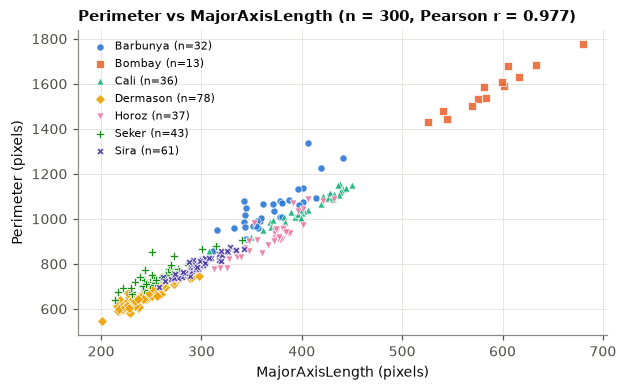

In [6]:
# Figure 1 - relationship between MajorAxisLength and Perimeter (colour + marker = bean class)
fig, ax = plt.subplots(figsize=(6.2, 3.6))
for cls in CLASS_ORDER:
    d = s1[s1["Class"] == cls]
    ax.scatter(d["MajorAxisLength"], d["Perimeter"], s=22, marker=CLASS_MARKERS[cls],
               color=CLASS_COLOURS[cls], edgecolor="white", linewidth=0.5, alpha=0.9,
               label=f"{cls.title()} (n={len(d)})")
ax.set_xlabel("MajorAxisLength (pixels)")
ax.set_ylabel("Perimeter (pixels)")
ax.set_title(f"Perimeter vs MajorAxisLength (n = 300, Pearson r = {pearson_r:.3f})", loc="left")
ax.legend(loc="upper left", ncol=1, fontsize=7.5, handletextpad=0.3)
save_fig(fig, "fig1_t1_scatter")

In [7]:
# Simple linear regression: Perimeter (dependent) ~ MajorAxisLength (independent).
# An 80/20 random split lets us judge how well the fitted line generalises to unseen beans.
X1 = s1[["MajorAxisLength"]]
y1 = s1["Perimeter"]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=RANDOM_STATE)

lin_reg = LinearRegression().fit(X1_train, y1_train)
b0, b1 = lin_reg.intercept_, lin_reg.coef_[0]
print(f"Fitted model:  Perimeter = {b0:.3f} + {b1:.4f} x MajorAxisLength")

# 95% confidence intervals of the coefficients (ordinary least squares standard errors)
x_tr, n_tr = X1_train["MajorAxisLength"].to_numpy(), len(X1_train)
resid_tr = y1_train - lin_reg.predict(X1_train)
s2_err = (resid_tr ** 2).sum() / (n_tr - 2)                       # residual variance
sxx = ((x_tr - x_tr.mean()) ** 2).sum()
se_b1 = np.sqrt(s2_err / sxx)
se_b0 = np.sqrt(s2_err * (1 / n_tr + x_tr.mean() ** 2 / sxx))
t_crit = stats.t.ppf(0.975, df=n_tr - 2)
print(f"95% CI slope:     [{b1 - t_crit * se_b1:.4f}, {b1 + t_crit * se_b1:.4f}]")
print(f"95% CI intercept: [{b0 - t_crit * se_b0:.3f}, {b0 + t_crit * se_b0:.3f}]")


def regression_metrics(y_true, y_pred):
    """R2 (explained variance), RMSE/MAE (error in pixels) and MAPE (relative error)."""
    return {"R2": r2_score(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "MAPE (%)": 100 * mean_absolute_percentage_error(y_true, y_pred)}


reg_results = pd.DataFrame({"Train (n=240)": regression_metrics(y1_train, lin_reg.predict(X1_train)),
                            "Test (n=60)": regression_metrics(y1_test, lin_reg.predict(X1_test))}).T
print("\n", reg_results.round(3))

# 10-fold cross-validation on all 300 rows checks that the test result is not a lucky split
cv_reg = cross_validate(LinearRegression(), X1, y1, cv=KFold(10, shuffle=True, random_state=RANDOM_STATE),
                        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error"})
print(f"\n10-fold CV: R2 = {cv_reg['test_R2'].mean():.3f} +/- {cv_reg['test_R2'].std():.3f}, "
      f"RMSE = {-cv_reg['test_RMSE'].mean():.2f} +/- {cv_reg['test_RMSE'].std():.2f}")

Fitted model:  Perimeter = 53.895 + 2.5201 x MajorAxisLength
95% CI slope:     [2.4471, 2.5931]
95% CI intercept: [29.476, 78.314]

                   R2    RMSE     MAE  MAPE (%)
Train (n=240)  0.951  48.955  35.352     3.979
Test (n=60)    0.971  34.604  27.287     3.398

10-fold CV: R2 = 0.953 +/- 0.019, RMSE = 45.11 +/- 12.68


In [8]:
# Residual analysis: are errors random, or do they depend on the bean type (shape)?
s1_res = s1.assign(Fitted=lin_reg.predict(X1), Residual=y1 - lin_reg.predict(X1))
res_by_class = (s1_res.groupby("Class")
                .agg(n=("Residual", "size"), mean_residual=("Residual", "mean"),
                     sd_residual=("Residual", "std"), mean_roundness=("roundness", "mean"),
                     mean_aspect_ratio=("AspectRation", "mean"))
                .sort_values("mean_residual"))
print(res_by_class.round(3))
print(f"\nCorrelation(residual, AspectRation) = {s1_res['Residual'].corr(s1_res['AspectRation']):.3f}")

           n  mean_residual  sd_residual  mean_roundness  mean_aspect_ratio
Class                                                                      
HOROZ     37        -61.074       35.501           0.789              1.997
CALI      36        -25.641       18.950           0.852              1.710
DERMASON  78        -11.621       19.063           0.908              1.497
SIRA      61         -8.783       16.020           0.886              1.554
BOMBAY    13         36.508       27.708           0.870              1.578
SEKER     43         45.470       29.613           0.927              1.260
BARBUNYA  32         58.715       58.526           0.804              1.544

Correlation(residual, AspectRation) = -0.721


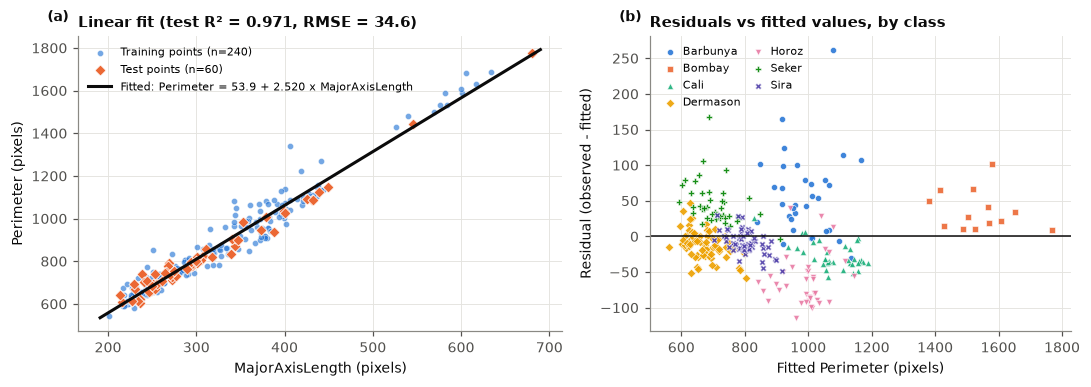

In [9]:
# Figure 2 - (a) data with the fitted line, (b) residuals vs fitted values
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
ax.scatter(X1_train["MajorAxisLength"], y1_train, s=16, color=PALETTE[0], alpha=0.65,
           edgecolor="white", linewidth=0.4, label="Training points (n=240)")
ax.scatter(X1_test["MajorAxisLength"], y1_test, s=26, marker="D", color=PALETTE[1],
           edgecolor="white", linewidth=0.5, label="Test points (n=60)")
x_line = np.linspace(X1["MajorAxisLength"].min() - 10, X1["MajorAxisLength"].max() + 10, 200)
ax.plot(x_line, b0 + b1 * x_line, color=INK, linewidth=2,
        label=f"Fitted: Perimeter = {b0:.1f} + {b1:.3f} x MajorAxisLength")
ax.set_xlabel("MajorAxisLength (pixels)")
ax.set_ylabel("Perimeter (pixels)")
ax.set_title(f"Linear fit (test R² = {reg_results.loc['Test (n=60)', 'R2']:.3f}, "
             f"RMSE = {reg_results.loc['Test (n=60)', 'RMSE']:.1f})", loc="left")
ax.legend(loc="upper left", fontsize=7.5)
panel_label(ax, "(a)")

ax = axes[1]
for cls in CLASS_ORDER:
    d = s1_res[s1_res["Class"] == cls]
    ax.scatter(d["Fitted"], d["Residual"], s=16, marker=CLASS_MARKERS[cls], color=CLASS_COLOURS[cls],
               edgecolor="white", linewidth=0.4, alpha=0.9, label=cls.title())
ax.axhline(0, color=INK, linewidth=1)
ax.set_xlabel("Fitted Perimeter (pixels)")
ax.set_ylabel("Residual (observed - fitted)")
ax.set_title("Residuals vs fitted values, by class", loc="left")
ax.legend(ncol=2, fontsize=7, loc="upper left", handletextpad=0.2, columnspacing=0.6)
panel_label(ax, "(b)")
fig.tight_layout()
save_fig(fig, "fig2_t1_fit_residuals")

# Task 2: Classification

In [10]:
# Task 2 code
# Load the saved Task 2 sample; all 16 morphological variables are inputs, Class is the target
s2 = pd.read_csv(SAMPLE_TWO)
assert s2.shape[0] == 2000 and s2.notna().all().all()
X2 = s2.drop(columns="Class")
y2 = s2["Class"].astype(str)
print("Class distribution in Sample Two:\n", y2.value_counts().to_string())

# Stratified 80/20 hold-out split, created ONCE and re-used by every classifier below.
# Stratification keeps the class proportions (incl. the small BOMBAY class) equal in both sets.
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, stratify=y2, random_state=RANDOM_STATE)
print(f"\nTraining set: {X2_train.shape}, Test set: {X2_test.shape}")

# Model selection uses ONLY the training data: 10-fold stratified CV repeated 3 times (30 folds)
# gives a more stable estimate than a single CV run. Macro-F1 weights every class equally,
# which matters because the classes are imbalanced (BOMBAY ~4%, DERMASON ~27%).
CV_CLF = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)
SCORING = {"f1_macro": "f1_macro", "accuracy": "accuracy"}


def classification_metrics(y_true, y_pred):
    """Test-set metrics used for every classifier (macro-averaged = each class counts equally)."""
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "F1 (macro)": f1_score(y_true, y_pred, average="macro", zero_division=0)}

Class distribution in Sample Two:
 Class
DERMASON    546
SIRA        400
HOROZ       286
SEKER       273
CALI        225
BARBUNYA    190
BOMBAY       80

Training set: (1600, 16), Test set: (400, 16)


## 2.1 k-Nearest Neighbours (kNN)

In [11]:
# kNN is distance-based, so features must share a common scale: Area is ~10^4-10^5 pixels while
# ShapeFactor2 is ~10^-3. StandardScaler is placed INSIDE the pipeline so that, in every CV fold,
# the mean/std are learnt from the training folds only (no information leaks from validation data).
knn_pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
k_values = list(range(1, 41))
knn_search = GridSearchCV(knn_pipe, {"knn__n_neighbors": k_values}, cv=CV_CLF,
                          scoring=SCORING, refit="f1_macro", n_jobs=-1)
knn_search.fit(X2_train, y2_train)

knn_cv = pd.DataFrame(knn_search.cv_results_)
best_k = knn_search.best_params_["knn__n_neighbors"]
print(f"Best k = {best_k}: CV macro-F1 = {knn_search.best_score_:.4f}, "
      f"CV accuracy = {knn_cv.loc[knn_search.best_index_, 'mean_test_accuracy']:.4f}")
print("\nCV macro-F1 for selected k values:")
print(knn_cv.set_index("param_knn__n_neighbors")[["mean_test_f1_macro", "std_test_f1_macro"]]
      .loc[[1, 3, 5, 9, 13, 15, best_k, 25, 30, 40]].round(4))

# Justification of the preprocessing: the same search WITHOUT scaling
unscaled = GridSearchCV(KNeighborsClassifier(), {"n_neighbors": k_values}, cv=CV_CLF,
                        scoring="f1_macro", n_jobs=-1).fit(X2_train, y2_train)
print(f"\nWithout standardisation: best k = {unscaled.best_params_['n_neighbors']}, "
      f"CV macro-F1 = {unscaled.best_score_:.4f}  (vs {knn_search.best_score_:.4f} with scaling)")

Best k = 14: CV macro-F1 = 0.9314, CV accuracy = 0.9185

CV macro-F1 for selected k values:
                        mean_test_f1_macro  std_test_f1_macro
param_knn__n_neighbors                                       
1                                   0.9073             0.0142
3                                   0.9218             0.0128
5                                   0.9251             0.0145
9                                   0.9276             0.0181
13                                  0.9296             0.0151
15                                  0.9275             0.0160
14                                  0.9314             0.0173
25                                  0.9236             0.0177
30                                  0.9242             0.0178
40                                  0.9221             0.0151



Without standardisation: best k = 1, CV macro-F1 = 0.6314  (vs 0.9314 with scaling)


In [12]:
# Final evaluation of the tuned kNN on the untouched test set
knn_best = knn_search.best_estimator_
y_pred_knn = knn_best.predict(X2_test)
test_results = {f"kNN (k={best_k})": classification_metrics(y2_test, y_pred_knn)}
print(pd.DataFrame(test_results).T.round(4))
print("\n", classification_report(y2_test, y_pred_knn, digits=3))
cm_knn = confusion_matrix(y2_test, y_pred_knn, labels=CLASS_ORDER)

            Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
kNN (k=14)    0.9225             0.9314           0.927       0.929

               precision    recall  f1-score   support

    BARBUNYA      0.917     0.868     0.892        38
      BOMBAY      1.000     1.000     1.000        16
        CALI      0.870     0.889     0.879        45
    DERMASON      0.927     0.927     0.927       109
       HOROZ      0.964     0.947     0.956        57
       SEKER      0.963     0.945     0.954        55
        SIRA      0.880     0.912     0.896        80

    accuracy                          0.922       400
   macro avg      0.931     0.927     0.929       400
weighted avg      0.923     0.922     0.923       400



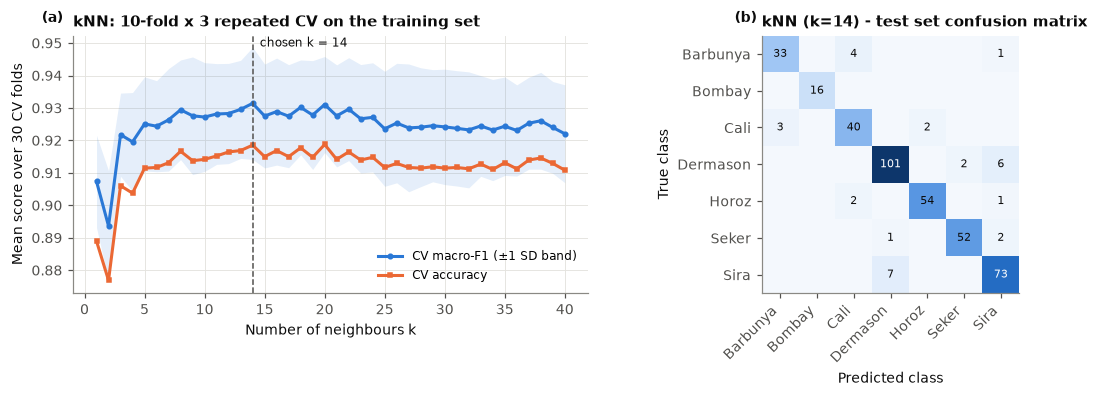

In [13]:
def plot_confusion(ax, cm, title):
    """Heat-map of a confusion matrix with counts written in each cell."""
    ax.imshow(cm, cmap=BLUES)
    ax.grid(False)
    ticks = [c.title() for c in CLASS_ORDER]
    ax.set_xticks(range(len(ticks)), ticks, rotation=45, ha="right")
    ax.set_yticks(range(len(ticks)), ticks)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j]:
                ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7.5,
                        color="white" if cm[i, j] > cm.max() * 0.55 else INK)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title, loc="left")


# Figure 3 - (a) choice of k by cross-validation, (b) test confusion matrix of the chosen model
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
mean_f1, sd_f1 = knn_cv["mean_test_f1_macro"], knn_cv["std_test_f1_macro"]
ax.fill_between(k_values, mean_f1 - sd_f1, mean_f1 + sd_f1, color=PALETTE[0], alpha=0.12, linewidth=0)
ax.plot(k_values, mean_f1, color=PALETTE[0], marker="o", markersize=3, label="CV macro-F1 (±1 SD band)")
ax.plot(k_values, knn_cv["mean_test_accuracy"], color=PALETTE[1], marker="s", markersize=3,
        label="CV accuracy")
ax.axvline(best_k, color=INK_2, linestyle="--", linewidth=1)
ax.text(best_k + 0.6, 0.952, f"chosen k = {best_k}", fontsize=8, color=INK, va="top")
ax.set_xlabel("Number of neighbours k")
ax.set_ylabel("Mean score over 30 CV folds")
ax.set_title("kNN: 10-fold x 3 repeated CV on the training set", loc="left")
ax.legend(loc="lower right")
panel_label(ax, "(a)")
plot_confusion(axes[1], cm_knn, f"kNN (k={best_k}) - test set confusion matrix")
panel_label(axes[1], "(b)")
fig.tight_layout()
save_fig(fig, "fig3_t2_knn")

## 2.2B Advanced Improvement Strategy: Local Mean-based kNN

**Modification of the prediction mechanism.** Standard kNN finds the *k* nearest training points
over all classes and takes a **majority vote**. The modified classifier below changes *how
neighbours contribute* to the decision:

1. **Class-conditional neighbourhoods** - for a query *x*, the *k* nearest neighbours are found
   separately **inside every class** (each class gets exactly *k* representatives, so a frequent class
   such as DERMASON can no longer out-vote a rare class simply because it has more points nearby).
2. **Local mean (centroid) instead of votes** - the *k* neighbours of class *c* are averaged into a
   local mean vector *m_c(x)*. Averaging cancels the effect of individual noisy/outlying neighbours.
3. **Distance-based decision** - *x* is assigned to the class whose local mean is **closest**:
   *ŷ = argmin_c ||x − m_c(x)||*. The decision uses continuous distances, so there are no voting ties.

With *k = 1* this is exactly 1-NN; as *k* grows towards the class size it becomes a nearest-centroid
classifier, so *k* controls a smooth bias-variance trade-off (LMKNN, Mitani & Hamamoto, 2006).
A multi-scale extension (LMPNN, Gou et al., 2014) is also implemented: it computes local means of the
first 1, 2, ..., k neighbours and sums their distances with harmonic weights 1/j. Both variants are
implemented from scratch as scikit-learn compatible estimators, tuned with the **same CV folds**, and
evaluated on the **same test split** as the original kNN.

In [14]:
class LocalMeanKNN(BaseEstimator, ClassifierMixin):
    """Local mean-based k-nearest-neighbour classifier (implemented from scratch).

    variant="lmknn": distance from x to the mean of its k nearest neighbours in each class
                     (Mitani & Hamamoto, 2006); predict the class with the smallest distance.
    variant="lmpnn": local means of the first j = 1..k neighbours in each class; the class score is the
                     harmonic-weighted sum  sum_j (1/j) * ||x - mean_j||  (Gou et al., 2014).
    """

    def __init__(self, k=5, variant="lmknn"):
        self.k = k
        self.variant = variant

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        # Store the training points of each class and a nearest-neighbour index per class
        self.class_points_ = [X[y == c] for c in self.classes_]
        self.class_index_ = [NearestNeighbors(n_neighbors=min(self.k, len(Xc))).fit(Xc)
                             for Xc in self.class_points_]
        return self

    def class_distances(self, X):
        """Return an (n_samples, n_classes) matrix: distance of each query to each class's local mean."""
        check_is_fitted(self)
        X = check_array(X)
        D = np.empty((X.shape[0], len(self.classes_)))
        for c, (Xc, index) in enumerate(zip(self.class_points_, self.class_index_)):
            _, idx = index.kneighbors(X)          # k nearest neighbours of every query INSIDE class c
            neigh = Xc[idx]                         # shape (n_queries, k, n_features), sorted by distance
            if self.variant == "lmknn":
                local_mean = neigh.mean(axis=1)                                   # one centroid per query
                D[:, c] = np.linalg.norm(X - local_mean, axis=1)
            else:  # "lmpnn"
                j = np.arange(1, neigh.shape[1] + 1)
                local_means = np.cumsum(neigh, axis=1) / j[None, :, None]         # means of first 1..k
                dists = np.linalg.norm(local_means - X[:, None, :], axis=2)
                D[:, c] = (dists / j).sum(axis=1)                                 # weights 1/j
        return D

    def predict(self, X):
        # Smallest (weighted) distance to a class's local mean wins - no majority vote
        return self.classes_[np.argmin(self.class_distances(X), axis=1)]


# Tune k for both variants with exactly the same pipeline (scaling inside CV), folds and metric
lm_searches = {}
for variant in ["lmknn", "lmpnn"]:
    pipe = Pipeline([("scaler", StandardScaler()), ("model", LocalMeanKNN(variant=variant))])
    lm_searches[variant] = GridSearchCV(pipe, {"model__k": k_values}, cv=CV_CLF, scoring=SCORING,
                                        refit="f1_macro", n_jobs=-1).fit(X2_train, y2_train)
    s = lm_searches[variant]
    print(f"{variant.upper()}: best k = {s.best_params_['model__k']}, CV macro-F1 = {s.best_score_:.4f}, "
          f"CV accuracy = {s.cv_results_['mean_test_accuracy'][s.best_index_]:.4f}")
print(f"Original kNN: best k = {best_k}, CV macro-F1 = {knn_search.best_score_:.4f}")

# Sensitivity to k: spread of the CV macro-F1 over k = 3..40 (smaller spread = more robust to k)
for name, res in [("kNN", knn_cv), ("LMKNN", pd.DataFrame(lm_searches["lmknn"].cv_results_)),
                  ("LMPNN", pd.DataFrame(lm_searches["lmpnn"].cv_results_))]:
    vals = res["mean_test_f1_macro"].to_numpy()[2:]
    print(f"{name:6s} CV macro-F1 over k=3..40: min {vals.min():.4f}, max {vals.max():.4f}, SD {vals.std():.4f}")

LMKNN: best k = 9, CV macro-F1 = 0.9359, CV accuracy = 0.9221


LMPNN: best k = 38, CV macro-F1 = 0.9338, CV accuracy = 0.9200
Original kNN: best k = 14, CV macro-F1 = 0.9314
kNN    CV macro-F1 over k=3..40: min 0.9196, max 0.9314, SD 0.0027
LMKNN  CV macro-F1 over k=3..40: min 0.9193, max 0.9359, SD 0.0032
LMPNN  CV macro-F1 over k=3..40: min 0.9189, max 0.9338, SD 0.0034


In [15]:
# Test-set evaluation (same split and metrics as the original kNN)
y_pred_lm = {}
for variant, label in [("lmknn", "LMKNN"), ("lmpnn", "LMPNN")]:
    s = lm_searches[variant]
    y_pred_lm[variant] = s.best_estimator_.predict(X2_test)
    test_results[f"{label} (k={s.best_params_['model__k']})"] = classification_metrics(y2_test, y_pred_lm[variant])
cmp_221 = pd.DataFrame(test_results).T
print(cmp_221.round(4))

# Per-class F1: where does the modification help?
per_class_f1 = pd.DataFrame({
    "kNN": f1_score(y2_test, y_pred_knn, labels=CLASS_ORDER, average=None),
    "LMKNN": f1_score(y2_test, y_pred_lm["lmknn"], labels=CLASS_ORDER, average=None),
    "LMPNN": f1_score(y2_test, y_pred_lm["lmpnn"], labels=CLASS_ORDER, average=None)}, index=CLASS_ORDER)
print("\nPer-class test F1:\n", per_class_f1.round(3))
print("\nLMKNN confusion matrix:\n", confusion_matrix(y2_test, y_pred_lm["lmknn"], labels=CLASS_ORDER))

# Exact McNemar test: are kNN and LMKNN errors on the SAME test beans significantly different?
knn_ok, lm_ok = (y_pred_knn == y2_test.to_numpy()), (y_pred_lm["lmknn"] == y2_test.to_numpy())
only_knn, only_lm = int((knn_ok & ~lm_ok).sum()), int((~knn_ok & lm_ok).sum())
p_mcnemar = stats.binomtest(only_lm, only_knn + only_lm, 0.5).pvalue
print(f"\nMcNemar: only kNN correct = {only_knn}, only LMKNN correct = {only_lm}, exact p = {p_mcnemar:.3f}")

# Computational cost (prediction time on the 400 test beans)
for name, model in [("kNN", knn_best), ("LMKNN", lm_searches["lmknn"].best_estimator_)]:
    t0 = time.perf_counter(); model.predict(X2_test); print(f"{name} predict time: {time.perf_counter() - t0:.4f}s")

              Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
kNN (k=14)      0.9225             0.9314          0.9270      0.9290
LMKNN (k=9)     0.9350             0.9413          0.9345      0.9376
LMPNN (k=38)    0.9275             0.9370          0.9331      0.9347

Per-class test F1:
             kNN  LMKNN  LMPNN
BARBUNYA  0.892  0.892  0.907
BOMBAY    1.000  1.000  1.000
CALI      0.879  0.879  0.889
DERMASON  0.927  0.950  0.930
HOROZ     0.956  0.956  0.956
SEKER     0.954  0.972  0.963
SIRA      0.896  0.915  0.898

LMKNN confusion matrix:
 [[ 33   0   4   0   0   0   1]
 [  0  16   0   0   0   0   0]
 [  3   0  40   0   2   0   0]
 [  0   0   0 104   0   0   5]
 [  0   0   2   0  54   0   1]
 [  0   0   0   1   0  52   2]
 [  0   0   0   5   0   0  75]]

McNemar: only kNN correct = 2, only LMKNN correct = 7, exact p = 0.180
kNN predict time: 0.0062s
LMKNN predict time: 0.0151s


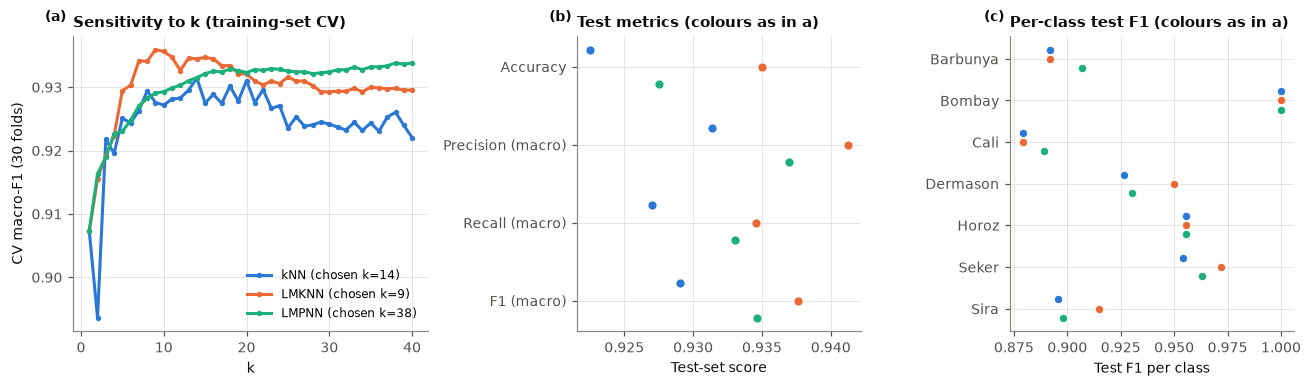

In [16]:
# Figure 4 - (a) CV macro-F1 vs k for the three classifiers, (b) test metrics, (c) per-class test F1
MODEL_COLOURS = {"kNN": PALETTE[0], "LMKNN": PALETTE[1], "LMPNN": PALETTE[2], "Decision Tree": PALETTE[6]}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.25, 1, 1]})
ax = axes[0]
chosen_k = {"kNN": best_k, "LMKNN": lm_searches["lmknn"].best_params_["model__k"],
            "LMPNN": lm_searches["lmpnn"].best_params_["model__k"]}
for name, res in [("kNN", knn_cv), ("LMKNN", pd.DataFrame(lm_searches["lmknn"].cv_results_)),
                  ("LMPNN", pd.DataFrame(lm_searches["lmpnn"].cv_results_))]:
    ax.plot(k_values, res["mean_test_f1_macro"], color=MODEL_COLOURS[name], marker="o", markersize=2.5,
            label=f"{name} (chosen k={chosen_k[name]})")
ax.set_xlabel("k")
ax.set_ylabel("CV macro-F1 (30 folds)")
ax.set_title("Sensitivity to k (training-set CV)", loc="left")
ax.legend(loc="lower right")
panel_label(ax, "(a)")

# Dot plot (not bars) so that small differences are visible without a truncated bar baseline
ax = axes[1]
metrics = list(cmp_221.columns)
for i, (row_name, row) in enumerate(cmp_221.iterrows()):
    key = row_name.split(" ")[0]
    ax.scatter(row.values, np.arange(len(metrics)) + (i - 1) * 0.22, s=36, color=MODEL_COLOURS[key],
               edgecolor="white", linewidth=0.6, label=row_name, zorder=3)
ax.set_yticks(range(len(metrics)), metrics)
ax.invert_yaxis()
ax.set_xlabel("Test-set score")
ax.set_title("Test metrics (colours as in a)", loc="left")
panel_label(ax, "(b)")

ax = axes[2]
for i, name in enumerate(["kNN", "LMKNN", "LMPNN"]):
    ax.scatter(per_class_f1[name], np.arange(len(CLASS_ORDER)) + (i - 1) * 0.22, s=30,
               color=MODEL_COLOURS[name], edgecolor="white", linewidth=0.6, label=name, zorder=3)
ax.set_yticks(range(len(CLASS_ORDER)), [c.title() for c in CLASS_ORDER])
ax.invert_yaxis()
ax.set_xlabel("Test F1 per class")
ax.set_title("Per-class test F1 (colours as in a)", loc="left")
panel_label(ax, "(c)")
fig.tight_layout()
save_fig(fig, "fig4_t2_modified_knn")

## 2.3 Decision Tree

In [17]:
# Decision trees split on one feature threshold at a time, so they are scale-invariant: no scaling needed.
# Key complexity parameters are tuned jointly with the SAME repeated CV folds and macro-F1 criterion:
#   max_depth        - maximum number of questions on a root-to-leaf path (main overfitting control)
#   min_samples_leaf - minimum beans per leaf (smooths decisions, removes tiny noisy leaves)
#   criterion        - impurity measure used to choose splits
dt_grid = {"max_depth": list(range(1, 21)) + [None],
           "min_samples_leaf": [1, 2, 5, 10, 20],
           "criterion": ["gini", "entropy"]}
dt_search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), dt_grid, cv=CV_CLF,
                         scoring=SCORING, refit="f1_macro", n_jobs=-1, return_train_score=True)
dt_search.fit(X2_train, y2_train)
dt_best = dt_search.best_estimator_
dt_cv = pd.DataFrame(dt_search.cv_results_)
print("Best parameters:", dt_search.best_params_)
print(f"CV macro-F1 = {dt_search.best_score_:.4f}, CV accuracy = "
      f"{dt_cv.loc[dt_search.best_index_, 'mean_test_accuracy']:.4f}")
print(f"Tree size: depth = {dt_best.get_depth()}, leaves = {dt_best.get_n_leaves()}")
print("\nTop 5 parameter combinations:")
print(dt_cv.sort_values("rank_test_f1_macro")[["params", "mean_test_f1_macro", "std_test_f1_macro"]]
      .head(5).to_string(index=False))

# A fully grown tree for comparison (shows why limiting complexity is needed)
full_tree = dt_cv[(dt_cv["param_max_depth"].isna()) & (dt_cv["param_min_samples_leaf"] == 1) &
                  (dt_cv["param_criterion"] == dt_search.best_params_["criterion"])]
print(f"\nUnpruned tree: train macro-F1 = {full_tree['mean_train_f1_macro'].iloc[0]:.4f}, "
      f"CV macro-F1 = {full_tree['mean_test_f1_macro'].iloc[0]:.4f}")

Best parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10}
CV macro-F1 = 0.9072, CV accuracy = 0.8925
Tree size: depth = 6, leaves = 38

Top 5 parameter combinations:
                                                           params  mean_test_f1_macro  std_test_f1_macro
 {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 10}            0.907205           0.020719
{'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 10}            0.904107           0.019930
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 10}            0.904107           0.019930
{'criterion': 'entropy', 'max_depth': 13, 'min_samples_leaf': 10}            0.904107           0.019930
{'criterion': 'entropy', 'max_depth': 18, 'min_samples_leaf': 10}            0.904107           0.019930

Unpruned tree: train macro-F1 = 1.0000, CV macro-F1 = 0.8950


In [18]:
# Test-set evaluation with the same metrics, and comparison with the ORIGINAL kNN from Task 2.1
y_pred_dt = dt_best.predict(X2_test)
cmp_23 = pd.DataFrame({f"kNN (k={best_k})": classification_metrics(y2_test, y_pred_knn),
                       "Decision Tree": classification_metrics(y2_test, y_pred_dt)}).T
cmp_23["CV macro-F1"] = [knn_search.best_score_, dt_search.best_score_]
print(cmp_23.round(4))
print("\n", classification_report(y2_test, y_pred_dt, digits=3))
print("Decision Tree confusion matrix:\n", confusion_matrix(y2_test, y_pred_dt, labels=CLASS_ORDER))

# Feature importance (total impurity reduction) - the interpretability advantage of the tree
importances = pd.Series(dt_best.feature_importances_, index=X2.columns).sort_values(ascending=False)
print("\nFeature importances:\n", importances.round(3).to_string())

# Training/prediction cost of the two models
for name, model in [("kNN", knn_best), ("Decision Tree", dt_best)]:
    t0 = time.perf_counter(); model.fit(X2_train, y2_train); t_fit = time.perf_counter() - t0
    t0 = time.perf_counter(); model.predict(X2_test); t_pred = time.perf_counter() - t0
    print(f"{name}: fit {t_fit * 1000:.1f} ms, predict {t_pred * 1000:.1f} ms")

               Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  CV macro-F1
kNN (k=14)       0.9225             0.9314          0.9270      0.9290       0.9314
Decision Tree    0.8725             0.8797          0.8788      0.8789       0.9072

               precision    recall  f1-score   support

    BARBUNYA      0.750     0.711     0.730        38
      BOMBAY      1.000     1.000     1.000        16
        CALI      0.809     0.844     0.826        45
    DERMASON      0.905     0.872     0.888       109
       HOROZ      0.914     0.930     0.922        57
       SEKER      0.981     0.945     0.963        55
        SIRA      0.800     0.850     0.824        80

    accuracy                          0.873       400
   macro avg      0.880     0.879     0.879       400
weighted avg      0.874     0.873     0.873       400

Decision Tree confusion matrix:
 [[27  0  9  0  0  0  2]
 [ 0 16  0  0  0  0  0]
 [ 4  0 38  0  3  0  0]
 [ 0  0  0 95  0  1 13]
 [ 1  0  0  1 53  0 

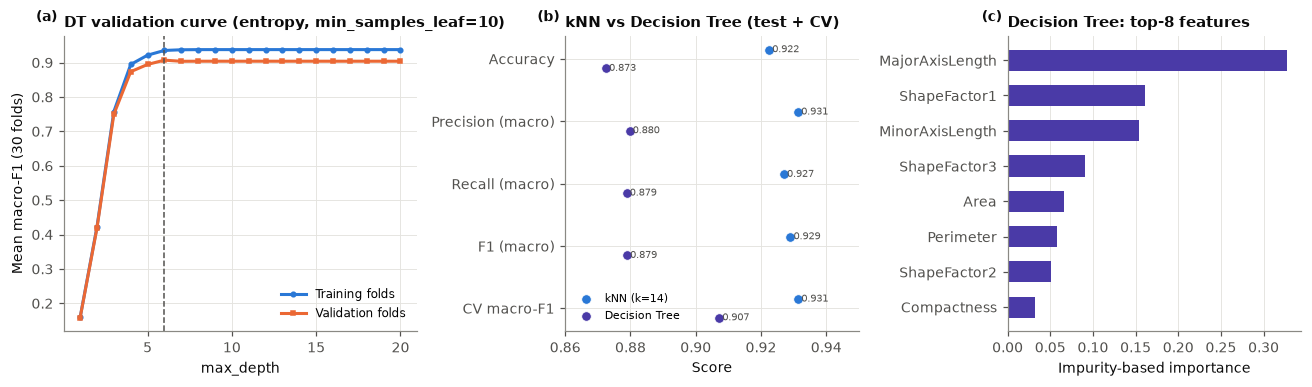

In [19]:
# Figure 5 - (a) validation curve over max_depth, (b) test metrics kNN vs DT, (c) feature importances
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.2, 1, 1]})
ax = axes[0]
best_leaf, best_crit = dt_search.best_params_["min_samples_leaf"], dt_search.best_params_["criterion"]
curve = dt_cv[(dt_cv["param_min_samples_leaf"] == best_leaf) & (dt_cv["param_criterion"] == best_crit)
              & dt_cv["param_max_depth"].notna()].sort_values("param_max_depth")
depths = curve["param_max_depth"].astype(int)
ax.plot(depths, curve["mean_train_f1_macro"], color=PALETTE[0], marker="o", markersize=3, label="Training folds")
ax.plot(depths, curve["mean_test_f1_macro"], color=PALETTE[1], marker="s", markersize=3, label="Validation folds")
ax.axvline(dt_search.best_params_["max_depth"], color=INK_2, linestyle="--", linewidth=1)
ax.set_xlabel("max_depth")
ax.set_ylabel("Mean macro-F1 (30 folds)")
ax.set_title(f"DT validation curve ({best_crit}, min_samples_leaf={best_leaf})", loc="left")
ax.legend(loc="lower right")
panel_label(ax, "(a)")

ax = axes[1]
metrics = list(cmp_23.columns)
for i, (row_name, row) in enumerate(cmp_23.iterrows()):
    key = "kNN" if row_name.startswith("kNN") else "Decision Tree"
    ax.scatter(row.values, np.arange(len(metrics)) + (i - 0.5) * 0.3, s=40, color=MODEL_COLOURS[key],
               edgecolor="white", linewidth=0.6, label=row_name, zorder=3)
    for j, v in enumerate(row.values):
        ax.text(v, j + (i - 0.5) * 0.3, f" {v:.3f}", va="center", fontsize=6.5, color=INK_2)
ax.set_yticks(range(len(metrics)), metrics)
ax.invert_yaxis()
ax.set_xlim(0.86, 0.95)
ax.set_xlabel("Score")
ax.set_title("kNN vs Decision Tree (test + CV)", loc="left")
ax.legend(loc="lower left", fontsize=7)
panel_label(ax, "(b)")

ax = axes[2]
top = importances.head(8)[::-1]
ax.barh(top.index, top.values, color=MODEL_COLOURS["Decision Tree"], height=0.6)
ax.set_xlabel("Impurity-based importance")
ax.set_title("Decision Tree: top-8 features", loc="left")
ax.grid(axis="y", visible=False)
panel_label(ax, "(c)")
fig.tight_layout()
save_fig(fig, "fig5_t2_decision_tree")

# Task 3: Clustering

In [20]:
# Task 3 code
# Load the saved Task 3 sample. Class is separated immediately and is NEVER used to fit models or to
# choose parameters - it is used only afterwards for external evaluation (ARI/NMI, contingency tables).
s3 = pd.read_csv(SAMPLE_THREE)
assert s3.shape[0] == 2000 and s3.notna().all().all()
X3 = s3.drop(columns="Class")
y3_true = s3["Class"].astype(str).to_numpy()   # external labels - evaluation only

# Distance-based clustering needs comparable feature scales -> z-score standardisation
Z3 = StandardScaler().fit_transform(X3)
n_features = Z3.shape[1]

# Strong feature redundancy (relevant for k-Means, DBSCAN and PCA discussions)
corr = X3.corr().abs().to_numpy()
upper = corr[np.triu_indices(n_features, k=1)]
print(f"Feature pairs with |r| > 0.9: {(upper > 0.9).sum()} of {len(upper)}")


def knee_point(x, y):
    """Index of the 'knee/elbow' of a curve: the point farthest from the straight line
    joining its first and last points (both axes normalised to [0, 1])."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    xn, yn = (x - x.min()) / (x.max() - x.min()), (y - y.min()) / (y.max() - y.min())
    dist = np.abs((yn[-1] - yn[0]) * xn - (xn[-1] - xn[0]) * yn + xn[-1] * yn[0] - yn[-1] * xn[0])
    return int(np.argmax(dist))


def internal_metrics(Z, labels):
    """Silhouette (higher better), Davies-Bouldin (lower better), Calinski-Harabasz (higher better).
    Noise points (label -1, DBSCAN) are excluded because they belong to no cluster."""
    mask = labels != -1
    if len(np.unique(labels[mask])) < 2:
        return {"Silhouette": np.nan, "Davies-Bouldin": np.nan, "Calinski-Harabasz": np.nan}
    return {"Silhouette": silhouette_score(Z[mask], labels[mask]),
            "Davies-Bouldin": davies_bouldin_score(Z[mask], labels[mask]),
            "Calinski-Harabasz": calinski_harabasz_score(Z[mask], labels[mask])}


def external_metrics(labels):
    """Agreement with the (hidden) bean classes; noise is treated as its own group."""
    return {"ARI": adjusted_rand_score(y3_true, labels), "NMI": normalized_mutual_info_score(y3_true, labels),
            "Homogeneity": homogeneity_score(y3_true, labels), "Completeness": completeness_score(y3_true, labels)}

Feature pairs with |r| > 0.9: 21 of 120


## 3.1 k-Means

In [21]:
# Run k-Means (k-means++ initialisation, 10 restarts) for k = 2..12 and record internal metrics
k_range = list(range(2, 13))
km_rows = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z3)
    km_rows.append({"k": k, "Inertia (SSE)": km.inertia_, **internal_metrics(Z3, km.labels_),
                    **external_metrics(km.labels_)})
km_table = pd.DataFrame(km_rows).set_index("k")
print(km_table.round(3))

# Choose k from INTERNAL criteria only (labels are not allowed to influence the choice)
votes = {"Elbow (inertia knee)": k_range[knee_point(k_range, km_table["Inertia (SSE)"])],
         "Max silhouette": km_table["Silhouette"].idxmax(),
         "Min Davies-Bouldin": km_table["Davies-Bouldin"].idxmin(),
         "Max Calinski-Harabasz": km_table["Calinski-Harabasz"].idxmax()}
print("\nk suggested by each criterion:", votes)
# Majority vote; a tie would be broken by the silhouette criterion
vote_counts = pd.Series(list(votes.values())).value_counts()
k_best = int(vote_counts.index[0]) if vote_counts.iloc[0] > 1 else int(votes["Max silhouette"])
print(f"Chosen k = {k_best}")

    Inertia (SSE)  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI  Homogeneity  Completeness
k                                                                                                        
2       19016.980       0.394           1.078           1364.060  0.284  0.438        0.300         0.811
3       13972.540       0.403           0.910           1288.271  0.306  0.495        0.359         0.800
4       11352.536       0.339           0.931           1210.077  0.443  0.605        0.492         0.785
5        9147.572       0.356           1.023           1245.975  0.567  0.708        0.624         0.819
6        8150.615       0.359           0.987           1166.922  0.552  0.685        0.623         0.761
7        7251.747       0.303           1.102           1133.595  0.653  0.721        0.712         0.731
8        6700.001       0.297           1.163           1074.575  0.690  0.740        0.755         0.726
9        6209.530       0.298           1.165 

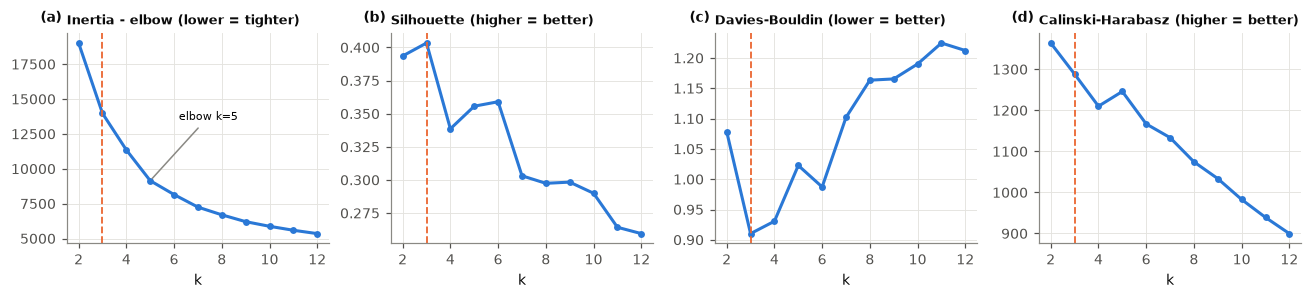

In [22]:
# Figure 6 - effect of k on the four internal criteria
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
panels = [("Inertia (SSE)", "Inertia - elbow", "lower = tighter"),
          ("Silhouette", "Silhouette", "higher = better"),
          ("Davies-Bouldin", "Davies-Bouldin", "lower = better"),
          ("Calinski-Harabasz", "Calinski-Harabasz", "higher = better")]
for i, (ax, (col, title, note)) in enumerate(zip(axes, panels)):
    ax.plot(k_range, km_table[col], color=PALETTE[0], marker="o", markersize=3.5)
    ax.axvline(k_best, color=PALETTE[1], linestyle="--", linewidth=1.2)
    ax.set_title(f"{title} ({note})", loc="left", fontsize=8.5)
    ax.set_xlabel("k")
    ax.set_xticks(k_range[::2])
    panel_label(ax, f"({'abcd'[i]})")
axes[0].annotate(f"elbow k={votes['Elbow (inertia knee)']}",
                 (votes["Elbow (inertia knee)"], km_table.loc[votes["Elbow (inertia knee)"], "Inertia (SSE)"]),
                 xytext=(6.2, 13500), fontsize=7.5, arrowprops=dict(arrowstyle="-", color=INK_3))
fig.tight_layout()
save_fig(fig, "fig6_t3_kmeans_k")

In [23]:
# Final k-Means model with the chosen k
kmeans = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit(Z3)
km_labels = kmeans.labels_
print("Cluster sizes:", np.bincount(km_labels))
print("\nInternal:", {m: round(v, 3) for m, v in internal_metrics(Z3, km_labels).items()})
print("External:", {m: round(v, 3) for m, v in external_metrics(km_labels).items()})

# External interpretation: which bean classes fall into which cluster?
print("\nContingency table (rows = clusters, columns = true classes):")
print(pd.crosstab(km_labels, y3_true, rownames=["cluster"], colnames=["class"]))

# Cluster profiles in original units: what distinguishes the clusters?
profile_cols = ["Area", "MajorAxisLength", "AspectRation", "Compactness", "roundness", "Solidity"]
print("\nCluster means (original units):")
print(X3.assign(cluster=km_labels).groupby("cluster")[profile_cols].mean().round(3))

# For reference only (NOT used for selection): k = 7, the number of registered varieties
print(f"\nReference only - k=7: ARI = {km_table.loc[7, 'ARI']:.3f}, silhouette = {km_table.loc[7, 'Silhouette']:.3f}")

Cluster sizes: [ 820 1098   82]

Internal: {'Silhouette': 0.403, 'Davies-Bouldin': 0.91, 'Calinski-Harabasz': 1288.271}
External: {'ARI': 0.306, 'NMI': 0.495, 'Homogeneity': 0.359, 'Completeness': 0.8}

Contingency table (rows = clusters, columns = true classes):
class    BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
cluster                                                      
0             190       0   247         5    274      0   104
1              17       0     0       525      4    295   257
2               1      81     0         0      0      0     0

Cluster means (original units):
               Area  MajorAxisLength  AspectRation  Compactness  roundness  Solidity
cluster                                                                             
0         64036.321          378.499         1.781        0.751      0.817     0.985
1         37236.887          259.339         1.432        0.838      0.914     0.989
2        172026.110          591.395         1.587   

## 3.2 DBSCAN

In [24]:
# MinPts: the rule of thumb MinPts = 2 x dimensionality (Sander et al., 1998; Schubert et al., 2017)
# -> 2 x 16 = 32. A larger MinPts makes density estimates more robust to noise in 16 dimensions.
min_pts = 2 * n_features

# Eps: k-distance graph - sort every point's distance to its MinPts-th nearest neighbour
# (sklearn counts the point itself, matching DBSCAN's definition of min_samples).
# Points left of the knee lie in dense regions; the steep part right of the knee are sparse/noise points.
k_dist = np.sort(NearestNeighbors(n_neighbors=min_pts).fit(Z3).kneighbors(Z3)[0][:, -1])
knee_idx = knee_point(np.arange(len(k_dist)), k_dist)
eps = round(float(k_dist[knee_idx]), 2)
print(f"MinPts = {min_pts}, eps (knee of the {min_pts}-distance graph) = {eps} "
      f"[{100 * knee_idx / len(k_dist):.1f}th percentile]")

# Sensitivity analysis over a grid of (eps, MinPts) to show the choice is not fragile
eps_grid = np.round(np.arange(1.0, 3.01, 0.25), 2)
minpts_grid = [8, 17, 32, 48]
sens = []
for mp in minpts_grid:
    for e in eps_grid:
        lab = DBSCAN(eps=e, min_samples=mp).fit_predict(Z3)
        sens.append({"MinPts": mp, "eps": e, "clusters": len(set(lab) - {-1}),
                     "noise %": 100 * np.mean(lab == -1), "ARI": adjusted_rand_score(y3_true, lab)})
sens = pd.DataFrame(sens)
print(sens.pivot(index="MinPts", columns="eps", values="clusters"))
print(sens.pivot(index="MinPts", columns="eps", values="noise %").round(1))

MinPts = 32, eps (knee of the 32-distance graph) = 2.48 [94.8th percentile]


eps     1.00  1.25  1.50  1.75  2.00  2.25  2.50  2.75  3.00
MinPts                                                      
8          4     3     3     2     2     1     1     1     1
17         4     1     2     2     2     2     1     1     1
32         1     4     1     1     2     2     2     2     1
48         1     2     3     1     1     2     2     2     2
eps     1.00  1.25  1.50  1.75  2.00  2.25  2.50  2.75  3.00
MinPts                                                      
8       24.8  11.5   4.4   2.9   1.7   1.2   0.8   0.4   0.4
17      38.7  17.4   8.7   3.8   2.4   1.6   0.8   0.7   0.5
32      48.4  30.4  13.4   8.1   3.4   2.1   1.4   1.0   0.6
48      53.3  39.2  21.0  10.1   7.1   3.4   1.6   1.2   0.8


In [25]:
# Final DBSCAN model
dbscan = DBSCAN(eps=eps, min_samples=min_pts).fit(Z3)
db_labels = dbscan.labels_
n_db_clusters = len(set(db_labels) - {-1})
print(f"Clusters found: {n_db_clusters}, noise points: {np.sum(db_labels == -1)} "
      f"({100 * np.mean(db_labels == -1):.1f}%)")
print("Cluster sizes:", np.bincount(db_labels[db_labels != -1]))
print("\nContingency table (rows = DBSCAN cluster, -1 = noise):")
print(pd.crosstab(db_labels, y3_true, rownames=["cluster"], colnames=["class"]))

# Consistent comparison: same standardised space, same internal + external metrics
noise_free = db_labels != -1
compare_32 = pd.DataFrame({
    f"k-Means (k={k_best})": {"Clusters": k_best, "Noise %": 0.0,
                              **internal_metrics(Z3, km_labels), **external_metrics(km_labels)},
    f"DBSCAN (eps={eps}, MinPts={min_pts})": {"Clusters": n_db_clusters, "Noise %": 100 * np.mean(~noise_free),
                                             **internal_metrics(Z3, db_labels), **external_metrics(db_labels)}}).T
print("\n", compare_32.round(3))
# Fairness check: k-Means silhouette computed only on the points DBSCAN did not label as noise
print(f"\nk-Means silhouette on DBSCAN's non-noise points: "
      f"{silhouette_score(Z3[noise_free], km_labels[noise_free]):.3f}")

Clusters found: 2, noise points: 27 (1.4%)
Cluster sizes: [1901   72]

Contingency table (rows = DBSCAN cluster, -1 = noise):
class    BARBUNYA  BOMBAY  CALI  DERMASON  HOROZ  SEKER  SIRA
cluster                                                      
-1              0       8     2         2     12      1     2
 0            208       1   245       528    266    294   359
 1              0      72     0         0      0      0     0

                               Clusters  Noise %  Silhouette  Davies-Bouldin  Calinski-Harabasz    ARI    NMI  Homogeneity  Completeness
k-Means (k=3)                      3.0     0.00       0.403           0.910           1288.271  0.306  0.495        0.359         0.800
DBSCAN (eps=2.48, MinPts=32)       2.0     1.35       0.554           0.529            557.304  0.034  0.158        0.089         0.724



k-Means silhouette on DBSCAN's non-noise points: 0.408


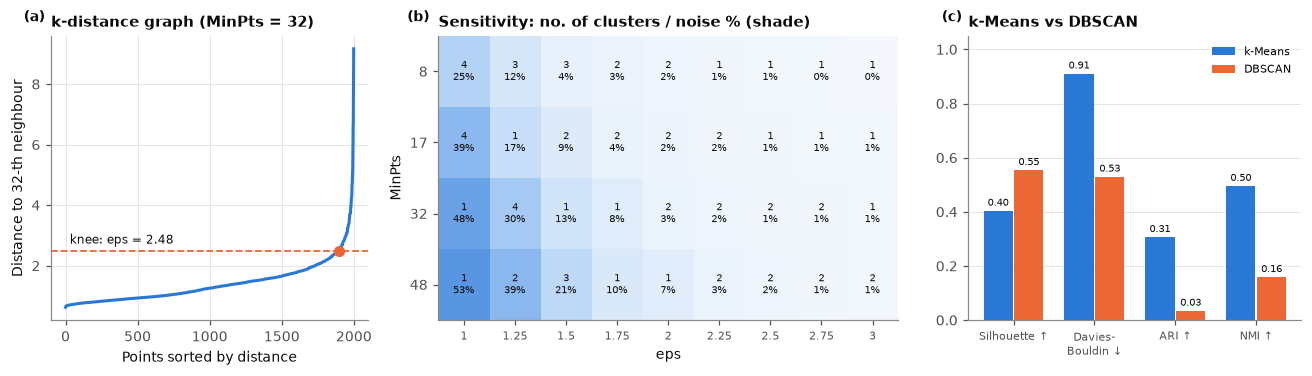

In [26]:
# Figure 7 - (a) k-distance graph with the knee, (b) DBSCAN sensitivity, (c) metric comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 1.45, 1.05]})
ax = axes[0]
ax.plot(np.arange(len(k_dist)), k_dist, color=PALETTE[0])
ax.axhline(eps, color=PALETTE[1], linestyle="--", linewidth=1.2)
ax.scatter([knee_idx], [eps], color=PALETTE[1], s=40, zorder=3)
ax.text(30, eps + 0.25, f"knee: eps = {eps}", fontsize=8, color=INK)
ax.set_xlabel("Points sorted by distance")
ax.set_ylabel(f"Distance to {min_pts}-th neighbour")
ax.set_title(f"k-distance graph (MinPts = {min_pts})", loc="left")
panel_label(ax, "(a)")

ax = axes[1]
pivot_c = sens.pivot(index="MinPts", columns="eps", values="clusters")
pivot_n = sens.pivot(index="MinPts", columns="eps", values="noise %")
ax.imshow(pivot_n.values, cmap=BLUES, aspect="auto", vmin=0, vmax=100)
ax.grid(False)
for i in range(pivot_c.shape[0]):
    for j in range(pivot_c.shape[1]):
        ax.text(j, i, f"{pivot_c.values[i, j]}\n{pivot_n.values[i, j]:.0f}%", ha="center", va="center",
                fontsize=6.5, color="white" if pivot_n.values[i, j] > 55 else INK)
ax.set_xticks(range(len(eps_grid)), [f"{e:g}" for e in eps_grid], fontsize=7.5)
ax.set_yticks(range(len(minpts_grid)), minpts_grid)
ax.set_xlabel("eps")
ax.set_ylabel("MinPts")
ax.set_title("Sensitivity: no. of clusters / noise % (shade)", loc="left")
panel_label(ax, "(b)")

# All four metrics lie on a 0-1(+) scale, so one shared axis is meaningful
ax = axes[2]
cmp_metrics = ["Silhouette", "Davies-Bouldin", "ARI", "NMI"]
for j, (name, colour) in enumerate(zip(compare_32.index, [PALETTE[0], PALETTE[1]])):
    vals = compare_32.loc[name, cmp_metrics].to_numpy(dtype=float)
    xs = np.arange(len(cmp_metrics)) + (j - 0.5) * 0.38
    ax.bar(xs, vals, width=0.36, color=colour, label=name.split(" (")[0])
    for x, v in zip(xs, vals):
        ax.text(x, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=6.8, color=INK)
ax.set_xticks(range(len(cmp_metrics)), ["Silhouette ↑", "Davies-\nBouldin ↓", "ARI ↑", "NMI ↑"], fontsize=7.5)
ax.set_ylim(0, 1.05)
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", fontsize=7.5)
ax.set_title("k-Means vs DBSCAN", loc="left")
panel_label(ax, "(c)")
fig.tight_layout()
save_fig(fig, "fig7_t3_dbscan")

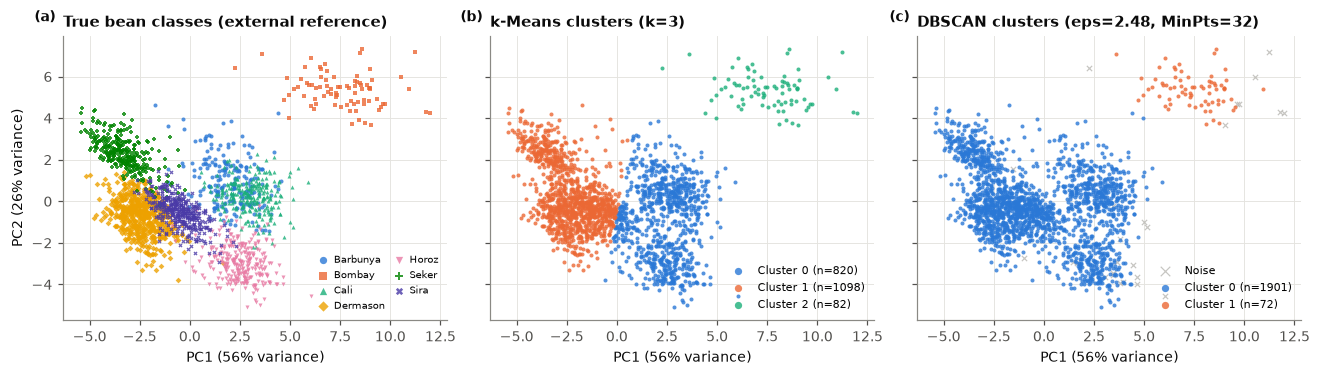

In [27]:
# Figure 8 - visual comparison on the first two principal components (projection used for display only)
pca_vis = PCA(n_components=2).fit(Z3)
V = pca_vis.transform(Z3)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for cls in CLASS_ORDER:
    m = y3_true == cls
    axes[0].scatter(V[m, 0], V[m, 1], s=7, marker=CLASS_MARKERS[cls], color=CLASS_COLOURS[cls],
                    alpha=0.8, linewidth=0, label=cls.title())
axes[0].set_title("True bean classes (external reference)", loc="left")
axes[0].legend(ncol=2, fontsize=6.5, markerscale=1.8, loc="lower right", handletextpad=0.1, columnspacing=0.4)
for ax, labels, title in [(axes[1], km_labels, f"k-Means clusters (k={k_best})"),
                          (axes[2], db_labels, f"DBSCAN clusters (eps={eps}, MinPts={min_pts})")]:
    for c in sorted(set(labels)):
        m = labels == c
        colour = NOISE_GREY if c == -1 else PALETTE[c]
        ax.scatter(V[m, 0], V[m, 1], s=7 if c != -1 else 12, color=colour, alpha=0.8,
                   marker="x" if c == -1 else "o", linewidth=0.8 if c == -1 else 0,
                   label="Noise" if c == -1 else f"Cluster {c} (n={m.sum()})")
    ax.set_title(title, loc="left")
    ax.legend(fontsize=7, markerscale=1.8, loc="lower right")
for i, ax in enumerate(axes):
    ax.set_xlabel(f"PC1 ({100 * pca_vis.explained_variance_ratio_[0]:.0f}% variance)")
    panel_label(ax, f"({'abc'[i]})")
axes[0].set_ylabel(f"PC2 ({100 * pca_vis.explained_variance_ratio_[1]:.0f}% variance)")
fig.tight_layout()
save_fig(fig, "fig8_t3_cluster_maps")

## 3.3B PCA Analysis

In [28]:
# PCA on the standardised inputs (PCA on raw data would be dominated by Area/ConvexArea, whose variance
# is ~10^15 times larger than that of the shape factors). All components are kept first for analysis.
pca_full = PCA().fit(Z3)
evr = pca_full.explained_variance_ratio_
pca_table = pd.DataFrame({"Eigenvalue": pca_full.explained_variance_, "Explained var %": 100 * evr,
                          "Cumulative %": 100 * np.cumsum(evr)},
                         index=[f"PC{i + 1}" for i in range(n_features)])
print(pca_table.head(8).round(3))

# Selection criteria for the number of components
criteria = {"Kaiser (eigenvalue > 1)": int((pca_full.explained_variance_ > 1).sum()),
            "Jolliffe (eigenvalue > 0.7)": int((pca_full.explained_variance_ > 0.7).sum()),
            "Cumulative >= 90%": int(np.argmax(np.cumsum(evr) >= 0.90) + 1),
            "Cumulative >= 95%": int(np.argmax(np.cumsum(evr) >= 0.95) + 1),
            "Scree elbow": knee_point(np.arange(1, n_features + 1), evr) + 1}
print("\n", criteria)
n_pc = criteria["Cumulative >= 90%"]
print(f"Selected number of components: {n_pc} ({100 * np.cumsum(evr)[n_pc - 1]:.1f}% of total variance)")

# Contribution of each variable to each retained component (squared loadings, in %)
loadings = pd.DataFrame(pca_full.components_[:n_pc].T, index=X3.columns,
                        columns=[f"PC{i + 1}" for i in range(n_pc)])
contrib = 100 * loadings ** 2
for pc in contrib.columns:
    top = contrib[pc].sort_values(ascending=False).head(4)
    print(f"{pc}: " + ", ".join(f"{f} {v:.1f}% ({'+' if loadings.loc[f, pc] > 0 else '-'})" for f, v in top.items()))

     Eigenvalue  Explained var %  Cumulative %
PC1       8.906           55.635        55.635
PC2       4.166           26.023        81.658
PC3       1.293            8.077        89.734
PC4       0.826            5.161        94.895
PC5       0.468            2.927        97.822
PC6       0.175            1.094        98.916
PC7       0.110            0.688        99.604
PC8       0.052            0.327        99.931

 {'Kaiser (eigenvalue > 1)': 3, 'Jolliffe (eigenvalue > 0.7)': 4, 'Cumulative >= 90%': 4, 'Cumulative >= 95%': 5, 'Scree elbow': 3}
Selected number of components: 4 (94.9% of total variance)
PC1: MajorAxisLength 10.6% (+), ShapeFactor2 9.9% (-), Perimeter 9.7% (+), EquivDiameter 8.9% (+)
PC2: MinorAxisLength 11.6% (+), AspectRation 11.4% (-), Compactness 11.3% (+), ShapeFactor3 11.2% (+)
PC3: Solidity 54.6% (+), ShapeFactor4 26.1% (+), roundness 3.6% (+), AspectRation 3.0% (+)
PC4: Extent 88.1% (+), ShapeFactor4 6.9% (-), Eccentricity 1.1% (+), ShapeFactor3 0.7% (-)


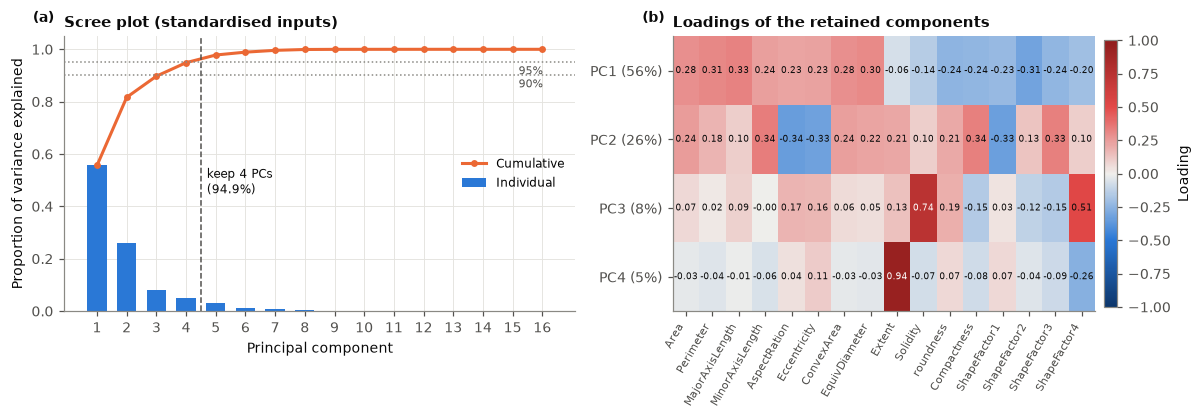

In [29]:
# Figure 9 - (a) scree plot with cumulative explained variance, (b) loadings of the retained components
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), gridspec_kw={"width_ratios": [1.15, 1]})
ax = axes[0]
pcs = np.arange(1, n_features + 1)
ax.bar(pcs, evr, color=PALETTE[0], width=0.65, label="Individual")
ax.plot(pcs, np.cumsum(evr), color=PALETTE[1], marker="o", markersize=3.5, label="Cumulative")
for thr in (0.90, 0.95):
    ax.axhline(thr, color=INK_3, linestyle=":", linewidth=1)
    ax.text(15.2, thr - 0.012, f"{int(thr * 100)}%", va="top", fontsize=7.5, color=INK_2)
ax.axvline(n_pc + 0.5, color=INK_2, linestyle="--", linewidth=1)
ax.text(n_pc + 0.7, 0.45, f"keep {n_pc} PCs\n({100 * np.cumsum(evr)[n_pc - 1]:.1f}%)", fontsize=8, color=INK)
ax.set_xticks(pcs)
ax.set_xlabel("Principal component")
ax.set_ylabel("Proportion of variance explained")
ax.set_title("Scree plot (standardised inputs)", loc="left")
ax.legend(loc="center right")
panel_label(ax, "(a)")

ax = axes[1]
im = ax.imshow(loadings.T.values, cmap=DIVERGING, vmin=-1, vmax=1, aspect="auto")
ax.grid(False)
ax.set_yticks(range(n_pc), [f"PC{i + 1} ({100 * evr[i]:.0f}%)" for i in range(n_pc)])
ax.set_xticks(range(n_features), X3.columns, rotation=60, ha="right", fontsize=7)
for i in range(n_pc):
    for j in range(n_features):
        v = loadings.values[j, i]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.6, color="white" if abs(v) > 0.6 else INK)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Loading")
ax.set_title("Loadings of the retained components", loc="left")
panel_label(ax, "(b)")
fig.tight_layout()
save_fig(fig, "fig9_t3_pca")

In [30]:
# k-Means on the PCA-transformed data. First re-check the choice of k inside the PCA space using the
# same internal criteria (labels still unused).
Z3_pca = pca_full.transform(Z3)[:, :n_pc]
pca_k_rows = []
for k in k_range:
    lab = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z3_pca)
    pca_k_rows.append({"k": k, **internal_metrics(Z3_pca, lab)})
pca_k_table = pd.DataFrame(pca_k_rows).set_index("k")
print("Best k in PCA space - silhouette:", pca_k_table["Silhouette"].idxmax(),
      "| Davies-Bouldin:", pca_k_table["Davies-Bouldin"].idxmin(),
      "| Calinski-Harabasz:", pca_k_table["Calinski-Harabasz"].idxmax())


def seed_stability(Z, k, n_runs=30):
    """Mean pairwise ARI between k-Means runs from different random initialisations (n_init=1).
    1.0 = the algorithm always converges to the same partition."""
    runs = [KMeans(n_clusters=k, n_init=1, random_state=s).fit_predict(Z) for s in range(n_runs)]
    return float(np.mean([adjusted_rand_score(a, b) for a, b in itertools.combinations(runs, 2)]))


def bootstrap_stability(Z, k, n_boot=20, frac=0.8):
    """Mean ARI between the full-data partition and partitions learnt on random 80% subsamples
    (subsample centroids are used to label all points). 1.0 = perfectly stable structure."""
    rng = np.random.default_rng(RANDOM_STATE)
    reference = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(Z), int(frac * len(Z)), replace=False)
        sub = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z[idx])
        scores.append(adjusted_rand_score(reference, sub.predict(Z)))
    return float(np.mean(scores))


def evaluate_space(Z, name):
    """Cluster one representation with k-Means (k = k_best) and collect every comparison metric."""
    t0 = time.perf_counter()
    lab = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)
    fit_time = time.perf_counter() - t0
    own = internal_metrics(Z, lab)
    return lab, {"Dimensions": Z.shape[1], "Silhouette (own space)": own["Silhouette"],
                 "Silhouette (original space)": silhouette_score(Z3, lab),
                 "Davies-Bouldin (own space)": own["Davies-Bouldin"],
                 "ARI vs classes": adjusted_rand_score(y3_true, lab),
                 "NMI vs classes": normalized_mutual_info_score(y3_true, lab),
                 "ARI vs original partition": adjusted_rand_score(km_labels, lab),
                 "Bootstrap stability": bootstrap_stability(Z, k_best),
                 "Seed stability": seed_stability(Z, k_best), "Fit time (ms)": 1000 * fit_time,
                 "Cluster sizes": sorted(np.bincount(lab).tolist(), reverse=True)}


# Compare: original 16 standardised variables vs 4 PCs vs 4 whitened PCs (each PC rescaled to unit
# variance - tests what happens if low-variance directions are given the same weight as PC1)
Z3_white = PCA(n_components=n_pc, whiten=True).fit_transform(Z3)
pca_compare, pca_labels = {}, {}
for Z, name in [(Z3, "Original (16 vars)"), (Z3_pca, f"PCA ({n_pc} PCs)"), (Z3_white, f"Whitened PCA ({n_pc} PCs)")]:
    pca_labels[name], pca_compare[name] = evaluate_space(Z, name)
pca_compare = pd.DataFrame(pca_compare).T
print(pca_compare.to_string(float_format=lambda v: f"{v:.3f}"))
print("\nContingency table: k-Means clusters in PCA space vs true classes")
print(pd.crosstab(pca_labels[f"PCA ({n_pc} PCs)"], y3_true, rownames=["cluster"], colnames=["class"]))

Best k in PCA space - silhouette: 3 | Davies-Bouldin: 3 | Calinski-Harabasz: 2


                     Dimensions Silhouette (own space) Silhouette (original space) Davies-Bouldin (own space) ARI vs classes NMI vs classes ARI vs original partition Bootstrap stability Seed stability Fit time (ms)    Cluster sizes
Original (16 vars)           16                  0.403                       0.403                      0.910          0.306          0.495                     1.000               0.997          0.841        86.021  [1098, 820, 82]
PCA (4 PCs)                   4                  0.421                       0.403                      0.862          0.304          0.492                     0.990               0.995          0.809        34.557  [1099, 819, 82]
Whitened PCA (4 PCs)          4                  0.241                       0.246                      1.516          0.243          0.325                     0.531               0.699          0.360        40.665  [960, 554, 486]

Contingency table: k-Means clusters in PCA space vs true classes
class 

In [31]:
# How does the NUMBER of retained components change the clustering? (dimensionality vs information)
Z3_all_pcs = pca_full.transform(Z3)
sweep = []
for m in range(1, n_features + 1):
    Zm = Z3_all_pcs[:, :m]
    lab = KMeans(n_clusters=k_best, n_init=10, random_state=RANDOM_STATE).fit_predict(Zm)
    sweep.append({"PCs": m, "Silhouette (own space)": silhouette_score(Zm, lab),
                  "Silhouette (original space)": silhouette_score(Z3, lab),
                  "ARI vs classes": adjusted_rand_score(y3_true, lab),
                  "NMI vs classes": normalized_mutual_info_score(y3_true, lab),
                  "ARI vs original partition": adjusted_rand_score(km_labels, lab),
                  "Seed stability": seed_stability(Zm, k_best), "Bootstrap stability": bootstrap_stability(Zm, k_best)})
sweep = pd.DataFrame(sweep).set_index("PCs")
print(sweep.round(3))

# Additional check with DBSCAN in the PCA space (same rules: MinPts = 2 x dims, eps from the knee)
mp_pca = 2 * n_pc
kd = np.sort(NearestNeighbors(n_neighbors=mp_pca).fit(Z3_pca).kneighbors(Z3_pca)[0][:, -1])
eps_pca = round(float(kd[knee_point(np.arange(len(kd)), kd)]), 2)
db_pca = DBSCAN(eps=eps_pca, min_samples=mp_pca).fit_predict(Z3_pca)
print(f"\nDBSCAN on {n_pc} PCs (eps={eps_pca}, MinPts={mp_pca}): clusters = {len(set(db_pca) - {-1})}, "
      f"noise = {100 * np.mean(db_pca == -1):.1f}%, ARI = {adjusted_rand_score(y3_true, db_pca):.3f}, "
      f"NMI = {normalized_mutual_info_score(y3_true, db_pca):.3f}")

     Silhouette (own space)  Silhouette (original space)  ARI vs classes  NMI vs classes  ARI vs original partition  Seed stability  Bootstrap stability
PCs                                                                                                                                                     
1                     0.650                        0.399           0.311           0.494                      0.937           0.681                0.968
2                     0.498                        0.403           0.304           0.492                      0.990           0.906                0.995
3                     0.454                        0.403           0.304           0.492                      0.990           0.787                0.995
4                     0.421                        0.403           0.304           0.492                      0.990           0.809                0.995
5                     0.411                        0.403           0.306          

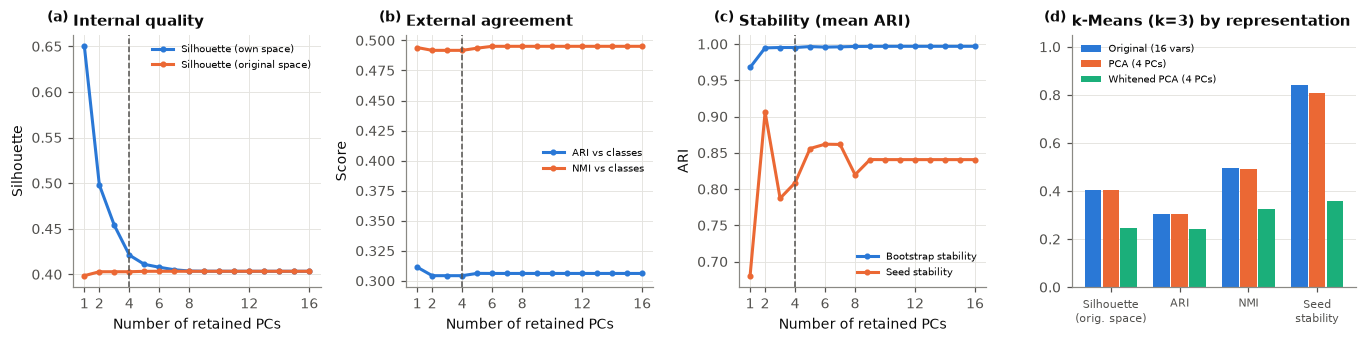

In [32]:
# Figure 10 - (a) internal quality, (b) external agreement, (c) stability vs number of retained PCs;
# (d) summary of the three representations
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2), gridspec_kw={"width_ratios": [1, 1, 1, 1.15]})
m_range = sweep.index
series = [(axes[0], ["Silhouette (own space)", "Silhouette (original space)"], "Internal quality", "Silhouette"),
          (axes[1], ["ARI vs classes", "NMI vs classes"], "External agreement", "Score"),
          (axes[2], ["Bootstrap stability", "Seed stability"], "Stability (mean ARI)", "ARI")]
for i, (ax, cols, title, ylabel) in enumerate(series):
    for j, col in enumerate(cols):
        ax.plot(m_range, sweep[col], color=PALETTE[j], marker="o", markersize=3, label=col)
    ax.axvline(n_pc, color=INK_2, linestyle="--", linewidth=1)
    ax.set_xlabel("Number of retained PCs")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left")
    ax.set_xticks([1, 2, 4, 6, 8, 12, 16])
    ax.legend(fontsize=6.8, loc=["upper right", "center right", "lower right"][i])
    panel_label(ax, f"({'abc'[i]})")

ax = axes[3]
show = ["Silhouette (original space)", "ARI vs classes", "NMI vs classes", "Seed stability"]
names = list(pca_compare.index)
width = 0.26
for j, name in enumerate(names):
    vals = pca_compare.loc[name, show].astype(float).to_numpy()
    ax.bar(np.arange(len(show)) + (j - 1) * width, vals, width=width * 0.92, color=PALETTE[j], label=name)
ax.set_xticks(range(len(show)), ["Silhouette\n(orig. space)", "ARI", "NMI", "Seed\nstability"], fontsize=7.5)
ax.set_ylim(0, 1.05)
ax.set_title(f"k-Means (k={k_best}) by representation", loc="left")
ax.legend(fontsize=6.5, loc="upper left")
ax.grid(axis="x", visible=False)
panel_label(ax, "(d)")
fig.tight_layout()
save_fig(fig, "fig10_t3_pca_clustering")